![image.png](https://i.imgur.com/a3uAqnb.png)

# 📝 Emotion Classification
A dataset of English Twitter messages with six basic emotions: anger, fear, joy, love, sadness, and surprise. For more detailed information please refer to the paper below.
The authors constructed a set of hashtags to collect a separate dataset of English tweets from the Twitter API belonging to eight basic emotions, including anger, anticipation, disgust, fear, joy, sadness, surprise, and trust. The data has already been preprocessed based on the approach described in their paper.

 [Emotion Dataset](https://www.kaggle.com/datasets/parulpandey/emotion-dataset/data).

##  Import Required Libraries


In [ ]:
!pip install emoji

In [ ]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud


## Load the Dataset
***Hint:***  Unique classes = ["sadness", "joy", "love", "anger", "fear", "surprise" ]


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("parulpandey/emotion-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'emotion-dataset' dataset.
Path to dataset files: /kaggle/input/emotion-dataset


## Exploratory Data Analysis (EDA)
***Hint***
* Disply sample of the dataset
* Check for missing and duplicated values
* Plot the distribution of emotions
* Explore average text length per emotion class ....


In [ ]:
train_df = pd.read_csv(path + "/training.csv")
test_df = pd.read_csv(path + "/test.csv")
val_df = pd.read_csv(path + "/validation.csv")

In [ ]:
print(f'Training data: {train_df.shape}')
print(f'Test data: {test_df.shape}')
print(f'validation data: {val_df.shape}')

Training data: (16000, 2)
Test data: (2000, 2)
validation data: (2000, 2)


In [ ]:
df = pd.concat([train_df, test_df, val_df], axis=0, ignore_index=True)
print("Shape of merged dataset:", df.shape)

Shape of merged dataset: (20000, 2)


In [ ]:
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    20000 non-null  object
 1   label   20000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB


In [ ]:
df['text'].isna().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [ ]:
df.label.value_counts()

,count
label,
1,6760
0,5797
3,2709
4,2373
2,1641
5,719


In [ ]:
# Pick one random sample from each class
samples = df.groupby("label").apply(lambda x: x.sample(1, random_state=42))

samples = samples.reset_index(drop=True)[["text", "label"]]
samples

,text,label
0,i feel somewhat victimized,0
1,i feel virtuous and tough when i wear a hat je...,1
2,i feel like hes trying to be the one to comfor...,2
3,i was still feeling bitchy not sad,3
4,i feeling distressed,4
5,i woke up feeling dazed and confused,5


In [ ]:
label_mapping = { 0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}

In [ ]:
df["emotion"] = df["label"].map(label_mapping)
df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [ ]:
px.bar(df['emotion'].value_counts(ascending=True),template='seaborn')

In [ ]:
df["Words Per Tweet"] = df["text"].str.split().apply(len)
px.box(df,y='Words Per Tweet', color='label', template='gridon')

In [ ]:
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))
avg_length = df.groupby("emotion")["text_length"].mean().reset_index()
avg_length

,emotion,text_length
0,anger,19.247693
1,fear,18.743363
2,joy,19.427515
3,love,20.611822
4,sadness,18.412972
5,surprise,19.714882


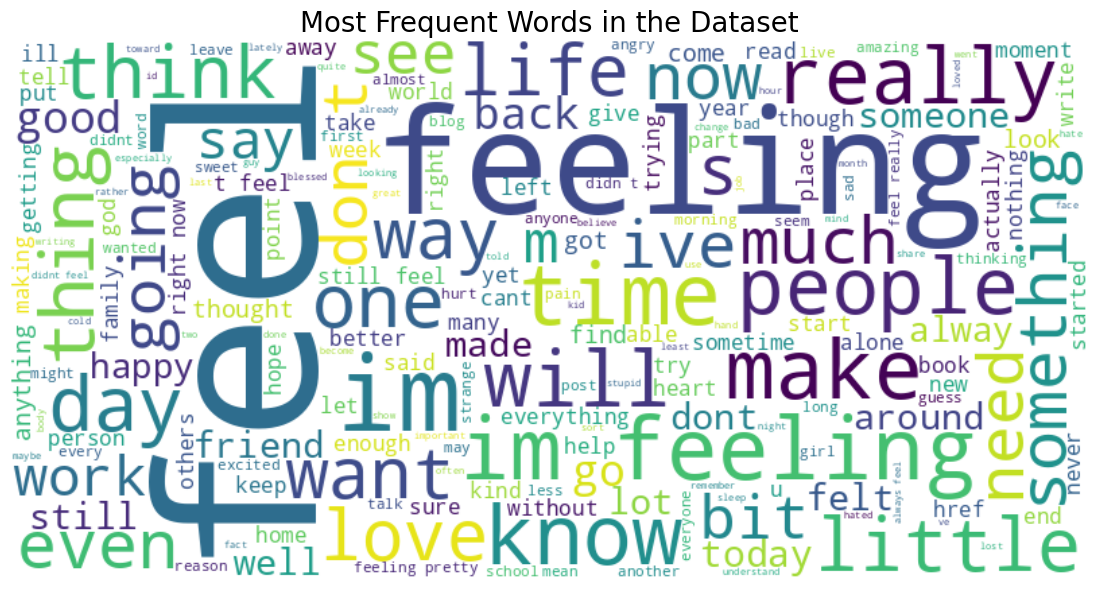

In [ ]:
# Combine all text into a single string
all_text = " ".join(df['text'].astype(str))

# Create the WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=200).generate(all_text)

# Plot the word cloud
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in the Dataset", fontsize=20)
plt.show()

##  Data Preprocessing
***Hint***
* Convert text to lowercase
* Remove punctuation, numbers, stopwords
* Tokenize and lemmatize words ...
* Transform text into numerical features (TF-IDF)


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import emoji
from textblob import TextBlob

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df

,text,label,emotion,Words Per Tweet,text_length
0,i didnt feel humiliated,0,sadness,4,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18,18
4,i am feeling grouchy,3,anger,4,4
...,...,...,...,...,...
19995,im having ssa examination tomorrow in the morn...,0,sadness,34,34
19996,i constantly worry about their fight against n...,1,joy,29,29
19997,i feel its important to share this info for th...,1,joy,15,15
19998,i truly feel that if you are passionate enough...,1,joy,19,19


In [ ]:
def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub(r'', text)

df['clean_text'] = df['text'].apply(remove_html_tags)
df[['clean_text','label','emotion']].head()

,clean_text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [ ]:
def remove_url(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'', text)

df['clean_text'] = df['clean_text'].apply(remove_url)
df[['clean_text','label','emotion']].head()

,clean_text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [ ]:
import string

punc = string.punctuation

def remove_punc(text):
    return text.translate(str.maketrans('', '', punc))

df['clean_text'] = df['clean_text'].apply(remove_punc)
df[['clean_text','label','emotion']].head()

,clean_text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [ ]:
chat_words = {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "B4N": "Bye For Now",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "ILU: I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See",
    "PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA?": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain",
    "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don't care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "BFF": "Best friends forever",
    "CSL": "Can't stop laughing"
}

def chat_conversion(text):
    new_text = []
    for i in text.split():
        if i.upper() in chat_words:
            new_text.append(chat_words[i.upper()])
        else:
            new_text.append(i)
    return " ".join(new_text)

df['clean_text'] = df['clean_text'].apply(chat_conversion)
df[['clean_text','label','emotion']].head()

,clean_text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [ ]:
stopword = stopwords.words('english')

def remove_stopwords(text):
    new_text = []

    for word in text.split():
        if word in stopword:
            new_text.append('')
        else:
            new_text.append(word)
    x = new_text[:]
    new_text.clear()
    return " ".join(x)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)
df[['clean_text','label','emotion']].head()

,clean_text,label,emotion
0,didnt feel humiliated,0,sadness
1,go feeling hopeless damned hopeful ar...,0,sadness
2,im grabbing minute post feel greedy wrong,3,anger
3,ever feeling nostalgic fireplace know ...,2,love
4,feeling grouchy,3,anger


In [ ]:
def spelling_correction(text):
    return TextBlob(text).correct().string

df['clean_text'] = df['clean_text'].apply(spelling_correction)
df[['clean_text','label','emotion']].head()

In [ ]:
def demojize_text(text):
    return emoji.demojize(text)

df['clean_text'] = df['clean_text'].apply(demojize_text)
df[['clean_text','label','emotion']].head()

,clean_text,label,emotion
0,didnt feel humiliated,0,sadness
1,go feeling hopeless damned hopeful ar...,0,sadness
2,im grabbing minute post feel greedy wrong,3,anger
3,ever feeling nostalgic fireplace know ...,2,love
4,feeling grouchy,3,anger


In [ ]:
tokenized_texts = []

for index, row in df.iterrows():
    tokenized_texts.append(word_tokenize(row['clean_text']))

df.insert(len(df.columns)-1, 'tokenized_text', tokenized_texts)

df.head()

,text,label,emotion,Words Per Tweet,text_length,tokenized_text,clean_text
0,i didnt feel humiliated,0,sadness,4,4,"[didnt, feel, humiliated]",didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,0,sadness,21,21,"[go, feeling, hopeless, damned, hopeful, aroun...",go feeling hopeless damned hopeful ar...
2,im grabbing a minute to post i feel greedy wrong,3,anger,10,10,"[im, grabbing, minute, post, feel, greedy, wrong]",im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,2,love,18,18,"[ever, feeling, nostalgic, fireplace, know, st...",ever feeling nostalgic fireplace know ...
4,i am feeling grouchy,3,anger,4,4,"[feeling, grouchy]",feeling grouchy


In [ ]:
# TF-IDF vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

## Train-Test Split


In [ ]:
# split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train Machine Learning Models
Train multiple models and compare results:
- Logistic Regression
- Naive Bayes
- Support Vector Machine (SVM)


In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
# Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [ ]:
# SVM
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

## Model Evaluation
Evaluate models with accuracy, precision, recall, F1-score, confusion matrix


In [ ]:
# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

print('Logistic Regression:\n', classification_report(y_test, y_pred_lr))
print('Naive Bayes:\n', classification_report(y_test, y_pred_nb))
print('SVM:\n', classification_report(y_test, y_pred_svm))

Logistic Regression:
               precision    recall  f1-score   support

       anger       0.91      0.81      0.85       536
        fear       0.86      0.76      0.81       456
         joy       0.83      0.96      0.89      1337
        love       0.88      0.65      0.74       325
     sadness       0.90      0.94      0.92      1193
    surprise       0.93      0.52      0.66       153

    accuracy                           0.87      4000
   macro avg       0.88      0.77      0.81      4000
weighted avg       0.87      0.87      0.86      4000

Naive Bayes:
               precision    recall  f1-score   support

       anger       0.96      0.28      0.44       536
        fear       0.88      0.23      0.37       456
         joy       0.61      0.97      0.75      1337
        love       0.95      0.06      0.12       325
     sadness       0.70      0.92      0.79      1193
    surprise       0.00      0.00      0.00       153

    accuracy                           0.

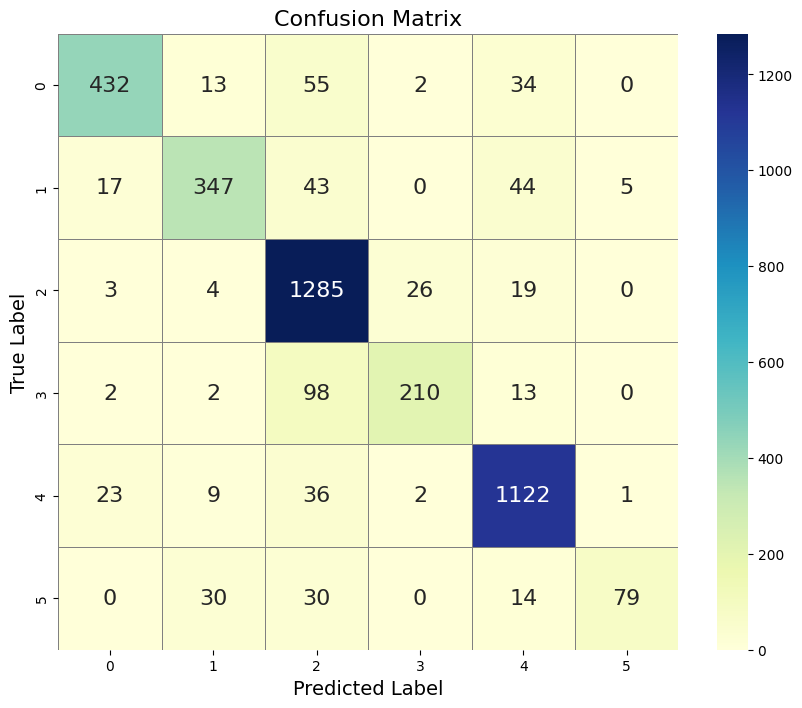

In [ ]:
# Plot confusion matrix for best model
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(10,8))  # make figure bigger
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=True, linewidths=0.5, linecolor='gray', annot_kws={"size":16})
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.show()